# Mean Reversion of Co-integrated Banking Basket vs. Sector ETF in the VN30
Basket:
*   Vietnam Technological and Commercial Joint Stock Bank (TCB)
*   Saigon Thuong Tin Commercial Joint Stock Bank (STB)

Sector ETF: SSIAM VNFIN LEAD ETF (FUESSVFL) replicates the Vietnam Leading Financial Index (VNFIN LEAD Index).


---

This is a quantitative statistical arbitrage strategy exploiting temporary price divergences between individual bank stocks and a broader financial sector ETF, betting on the eventual mean reversion of their price relationship.


**Final PnL:** +5.37% (highly defensive, unleveraged proof-of-concept)


This is an unleveraged proof-of-concept. The backtest exhibits significant cash drag because the algorithm only deploys 60% of capital intermittently. In a production environment, this strategy would be traded on portfolio margin to amplify the small, frequent spread captures into high-double-digit annualized returns.






# Methodology
**Custom spread indicator:** Spread = 0.5 x (TCB + STB) - FUESSVFL

**Signal generation:** Bollinger Band (50-period, 2.8 standard deviations)


*   Entry: triggered when spread breaches upper/lower bands
*   Exit: Positions flattened when spread reverts to moving average


**Quantitative techniques:**

'Spread bundle' sizing:

1.   Spread bundle sizing: Calculates position sizes based on 'spread bundles' to dynamically scale up volume while anchoring the 1:1:2 mathematical ratio of the custom spread equation, ensuring PnL strictly tracks Bollinger Band breaches and reversion.

*   Dynamically sizing positions based on equal-capital weighting violates equation coefficients and can lead to unhedged exposure if one leg moves significantly more than the others. This breaks the stationarity of the spread.
2.   Risk management: 5% stop-loss and 10% take-profit based on spread change from entry. Emergency eject notification to flatten all positions if any leg of the trade is rejected or canceled by the broker.


In [21]:
import matplotlib
import matplotlib.axes

# This 'Monkey Patch' fixes the error where Backtrader looks for an old
# Matplotlib name that was renamed years ago.
if not hasattr(matplotlib.axes.Axes, 'set_axis_bgcolor'):
    matplotlib.axes.Axes.set_axis_bgcolor = matplotlib.axes.Axes.set_facecolor

# This ensures the graph shows up inside the notebook
%matplotlib inline

In [22]:
!pip install backtrader


In [23]:
import backtrader as bt
from backtrader.indicators import BollingerBands
from datetime import datetime
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [24]:
%matplotlib inline

In [5]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
class CustomSpread(bt.Indicator):
    lines = ('spread',)
    def __init__(self):
        self.lines.spread = (self.data0.close + self.data1.close) / 2.0 - self.data2.close # Calculate spread as average of two banks minus FUESSVFL price

class SecondStrat(bt.Strategy):
    params = dict(
        stop_loss=0.05,  # 5% stop loss
        take_profit=0.10  # 10% take profit
    )

    def __init__(self):
        self.tcb = self.datas[0]
        self.stb = self.datas[1]
        self.fue = self.datas[2]
        self.spread = CustomSpread(self.tcb, self.stb, self.fue)
        self.boll = BollingerBands(self.spread, period=50, devfactor=2.8)

        self.entry_spread = None # Track entry spread for stop-loss/take-profit calculations
        self.position_type = None  # Long, Short, or None
        self.trade_log = [] # Store records of trades

    def log(self, txt):
        dt = self.datas[0].datetime.date(0)
        print(f'{dt}, {txt}')

    def notify_order(self, order):
        if order.status in [order.Completed]:
            action = 'BUY' if order.isbuy() else 'SELL'
            self.log(f'{action} {order.data._name} EXECUTED at {order.executed.price:.2f}')
        elif order.status in [order.Canceled, order.Margin, order.Rejected]:
            self.log(f'WARNING: Order {order.data._name} Canceled/Margin/Rejected')

            # Emergency ejection - Close all active positions immediately
            self.log('EMERGENCY EJECT: Closing all legs to prevent unhedged exposure.')
            self.close(data=self.tcb)
            self.close(data=self.stb)
            self.close(data=self.fue)
            self.position_type = None
            self.entry_spread = None

    def next(self):
        spread_val = self.spread[0]
        if not self.position_type:
            # ENTRY CONDITIONS:
            if spread_val < self.boll.lines.bot[0]: # spread < lower band. Long banks, short FUESSVFL
                size_tcb, size_stb, size_fue = self.calculate_safe_sizes()

                self.buy(data=self.tcb, size=size_tcb)
                self.buy(data=self.stb, size=size_stb)
                self.sell(data=self.fue, size=size_fue)

                self.entry_spread = spread_val
                self.position_type = 'long'
                self.log(f'ENTRY: LONG banks, SHORT FUESSVFL at spread={spread_val:.2f}')

            elif spread_val > self.boll.lines.top[0]: #spread > upper band. Short banks, long FUESSVFL
                size_tcb, size_stb, size_fue = self.calculate_safe_sizes()

                # FIX 1: Passing the actual calculated sizes into the orders!
                self.sell(data=self.tcb, size=size_tcb)
                self.sell(data=self.stb, size=size_stb)
                self.buy(data=self.fue, size=size_fue)

                self.entry_spread = spread_val
                self.position_type = 'short'
                self.log(f'ENTRY: SHORT banks, LONG FUESSVFL at spread={spread_val:.2f}')

        else:
            # EXIT CONDITIONS: Convergence (spread reverts within bands) post-breach
            if self.boll.lines.bot[0] < spread_val < self.boll.lines.top[0]:
                self.close(data=self.tcb)
                self.close(data=self.stb)
                self.close(data=self.fue)

                self.log(f'EXIT: Spread reverted to band center at spread={spread_val:.2f}, exited all positions')
                self.position_type = None
                self.entry_spread = None
                return

            # Stop-loss and take-profit logic
            if self.position_type == 'long':
                change = (spread_val - self.entry_spread) / abs(self.entry_spread)
            else:
                change = (self.entry_spread - spread_val) / abs(self.entry_spread)

            if change <= -self.params.stop_loss:
                self.close(data=self.tcb)
                self.close(data=self.stb)
                self.close(data=self.fue)
                self.log(f'EXIT: Stop-loss hit with spread change {change:.2%}')
                self.position_type = None
                self.entry_spread = None

            elif change >= self.params.take_profit:
                self.close(data=self.tcb)
                self.close(data=self.stb)
                self.close(data=self.fue)
                self.log(f'EXIT: Take-profit hit with spread change {change:.2%}')
                self.position_type = None
                self.entry_spread = None

    def notify_trade(self, trade):
        if trade.isclosed:
            dt = self.data.datetime.date(0)
            entry_price = trade.price

            self.log(
                f'TRADE CLOSED: {trade.data._name}, '
                f'PNL GROSS={trade.pnl:.2f}, PNL NET={trade.pnlcomm:.2f}, BARLEN={trade.barlen}'
            )

            self.trade_log.append({
                'Date': dt,
                'Instrument': trade.data._name,
                'Entry Price': f'{entry_price:.2f}',
                'PnL Gross': trade.pnl,
                'PnL Net': trade.pnlcomm,
                'Bars Held': trade.barlen
            })


    def stop(self):
        df = pd.DataFrame(self.trade_log)
        df.to_csv('/content/drive/MyDrive/qminh-trading-tvs/main/trade_log.csv', index=False)
        print(f"\nTrade log exported to trade_log.csv with {len(df)} trades.")

    def calculate_safe_sizes(self):
        """
        Calculates position sizes based on 'spread bundles' to dynamically scale up volume while
        anchoring the 1:1:2 mathematical ratio of the custom spread equation, ensuring PnL strictly
        tracks Bollinger Band breaches and reversion.

        Dynamically sizing positions based on equal-capital weighting violates equation coefficients
        and can lead to unhedged exposure if one leg moves significantly more than the others. This
        breaks the stationarity of the spread.

        """
        # 60% of total cash for the entire spread position
        target_cash = self.broker.get_cash() * 0.60

        # bundle = 1 share TCB + 1 share STB + 2 shares FUESSVFL
        bundle_cost = self.tcb.close[0] + self.stb.close[0] + (2 * self.fue.close[0])

        # Calculate number of bundles we can buy with the target cash, then multiply by the ratio to get individual sizes
        num_bundles = int(target_cash / bundle_cost)
        size_tcb = num_bundles * 1
        size_stb = num_bundles * 1
        size_fue = num_bundles * 2

        return size_tcb, size_stb, size_fue

Starting Portfolio Value: 1000000000.00
2020-07-27, ENTRY: LONG banks, SHORT FUESSVFL at spread=5450.00
2020-07-28, BUY TCB EXECUTED at 18200.00
2020-07-28, BUY STB EXECUTED at 10200.00
2020-07-28, SELL FUESSVFL EXECUTED at 8550.00
2020-07-28, EXIT: Spread reverted to band center at spread=5800.00, exited all positions
2020-07-29, SELL TCB EXECUTED at 18300.00
2020-07-29, SELL STB EXECUTED at 10250.00
2020-07-29, BUY FUESSVFL EXECUTED at 8430.00
2020-07-29, TRADE CLOSED: TCB, PNL GROSS=1312900.00, PNL NET=833691.50, BARLEN=1
2020-07-29, TRADE CLOSED: STB, PNL GROSS=656450.00, PNL NET=387961.95, BARLEN=1
2020-07-29, TRADE CLOSED: FUESSVFL, PNL GROSS=3150960.00, PNL NET=2705099.16, BARLEN=1
2020-09-28, ENTRY: SHORT banks, LONG FUESSVFL at spread=7915.00
2020-09-29, SELL TCB EXECUTED at 22900.00
2020-09-29, SELL STB EXECUTED at 13800.00
2020-09-29, BUY FUESSVFL EXECUTED at 10410.00
2020-09-29, EXIT: Spread reverted to band center at spread=7575.00, exited all positions
2020-09-30, BUY TCB

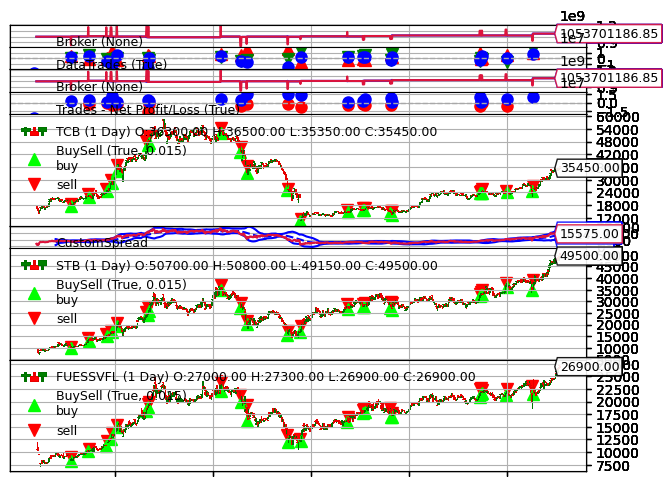

In [28]:
if __name__ == '__main__':
    cerebro = bt.Cerebro()
    cerebro.addstrategy(SecondStrat)

    # Define split ranges
    date_start = pd.to_datetime('2020-03-19')
    date_end = pd.to_datetime('2025-07-21')

    # Load full datasets as Pandas DataFrames
    df_fue = pd.read_csv('/content/drive/MyDrive/qminh-trading-tvs/main/data/fuess_final.csv', parse_dates=[0], dayfirst=True)
    df_fue = df_fue.sort_values(df_fue.columns[0])  # Sort by date ascending
    df_tcb = pd.read_csv('/content/drive/MyDrive/qminh-trading-tvs/main/data/tcb_final.csv', parse_dates=[0], dayfirst=True)
    df_tcb = df_tcb.sort_values(df_tcb.columns[0])  # Sort by date ascending
    df_stb = pd.read_csv('/content/drive/MyDrive/qminh-trading-tvs/main/data/stb_final.csv', parse_dates=[0], dayfirst=True)
    df_stb = df_stb.sort_values(df_stb.columns[0])  # Sort by date ascendings

    # Filter to train only
    df_fue_train = df_fue[(df_fue.iloc[:, 0] >= date_start) & (df_fue.iloc[:, 0] <= date_end)]
    df_tcb_train = df_tcb[(df_tcb.iloc[:, 0] >= date_start) & (df_tcb.iloc[:, 0] <= date_end)]
    df_stb_train = df_stb[(df_stb.iloc[:, 0] >= date_start) & (df_stb.iloc[:, 0] <= date_end)]

    # Define PandasData class
    class PandasData(bt.feeds.PandasData):
        params = (
            ('datetime', 0),
            ('open', 2),
            ('high', 3),
            ('low', 4),
            ('close', 1),
            ('volume', 5),
            ('openinterest', -1),
        )

    # Add data to Cerebro
    cerebro.adddata(PandasData(dataname=df_tcb_train), name='TCB')
    cerebro.adddata(PandasData(dataname=df_stb_train), name='STB')
    cerebro.adddata(PandasData(dataname=df_fue_train), name='FUESSVFL')

    # Broker setup
    cerebro.broker.setcash(1000000000) # 1 billion VND or 37,973.90 USD in starting capital
    cerebro.broker.setcommission(commission=0.001)
    cerebro.addobserver(bt.observers.Broker)
    cerebro.addobserver(bt.observers.Trades)

    print(f'Starting Portfolio Value: {cerebro.broker.getvalue():.2f}')
    cerebro.run(cheat_on_open=True)
    print(f'Ending Portfolio Value: {cerebro.broker.getvalue():.2f}')

    cerebro.plot(iplot=False, style='candlestick', barup='green', bardown='red', volume=False)
    plt.show()

# **Final PnL:** 53,701,186.9 VND (+5.37%) profit


This is an unleveraged proof-of-concept. The backtest exhibits significant cash drag because the algorithm only deploys 60% of capital intermittently. In a production environment, this strategy would be traded on portfolio margin to amplify the small, frequent spread captures into high-double-digit annualized returns.

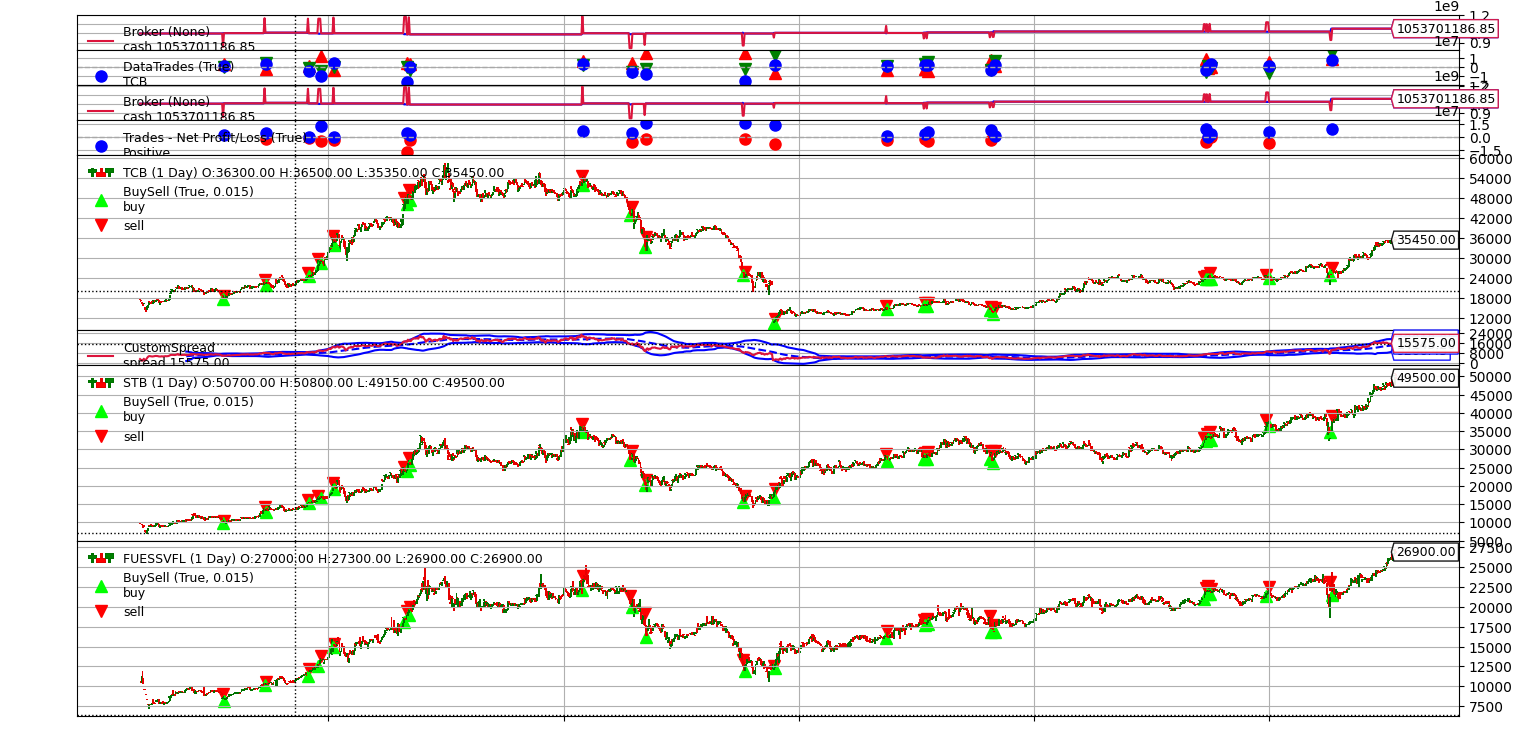